# Section 5.5, Figure 1

Shows double-scoring mask search followed by dense retraining of the masked network on FashionMNIST.

## Run Notes
- Run the notebook from top to bottom.
- Downloads FashionMNIST on first run.
- Compares dense training, masked retraining, and mask-search losses.
- Random sampling is intentionally exposed in the experiment cells so readers can vary it.

## Setup

In [1]:
import math

import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

# Prefer a GPU in Colab, fall back to Apple MPS when available, and use CPU otherwise.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

class ClassicNetwork(nn.Module):
    """Dense baseline with the same layer sizes as the masked model."""

    def __init__(self, layer_sizes, bias=True):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            *[
                block
                for layer in layer_sizes
                for block in [nn.Linear(layer[0], layer[1], bias=bias), nn.ReLU()]
            ][:-1]
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.linear_relu_stack(x)

def signed_kaiming_constant_(
    tensor,
    a=0,
    mode="fan_in",
    nonlinearity="relu",
    k=0.5,
    sparsity=0,
):
    """Initialize frozen weights with signed Kaiming-style uniform samples."""
    fan = nn.init._calculate_correct_fan(tensor, mode)
    gain = nn.init.calculate_gain(nonlinearity, a)
    std = gain / math.sqrt(fan)

    # The active subnetwork keeps a k-fraction of weights, so rescale by 1/sqrt(k).
    if k != 0:
        std *= 1 / math.sqrt(k)

    with torch.no_grad():
        tensor.uniform_(-std, std)
        if sparsity > 0:
            keep_mask = (torch.rand_like(tensor) > sparsity).float()
            tensor *= keep_mask
        return tensor

class GetSubnet(autograd.Function):
    """Straight-through top-k mask used by edge-popup."""

    @staticmethod
    def forward(ctx, scores, k=0.5):
        # Convert scores to a binary mask by keeping the largest k-fraction.
        out = scores.clone()
        _, idx = scores.flatten().sort()
        cutoff = int((1 - k) * scores.numel())
        flat_out = out.flatten()
        flat_out[idx[:cutoff]] = 0
        flat_out[idx[cutoff:]] = 1
        return out

    @staticmethod
    def backward(ctx, grad):
        # Straight-through estimator: pass score gradients through unchanged.
        return grad, None

class LinearSubnet(nn.Linear):
    """Linear layer whose training mode controls weights, scores, and masking."""

    def __init__(
        self,
        in_features,
        out_features,
        init=signed_kaiming_constant_,
        k=0.5,
        extra_capacity=0,
        double=True,
        **kwargs,
    ):
        super().__init__(in_features, out_features, **kwargs)
        multiplier = 2 if double else 1
        self.k = k
        self.mode = "mask"

        self.scores = nn.Parameter(
            torch.randn(out_features, multiplier * in_features + extra_capacity)
        )
        init(self.weight)
        self.weight.requires_grad_(False)

        if self.bias is not None:
            self.bias_scores = nn.Parameter(
                torch.randn(multiplier + extra_capacity, out_features)
            )
            self.bias.requires_grad_(False)

    def forward(self, x):
        if self.mode == "static":
            return F.linear(x, self.weight, self.bias)

        weight_mask = GetSubnet.apply(self.scores.abs(), self.k)
        weight = self.weight * weight_mask[:, : self.weight.shape[-1]]

        if self.bias is None:
            return F.linear(x, weight)

        bias_mask = GetSubnet.apply(self.bias_scores.abs(), self.k)
        bias = self.bias * bias_mask[1, : self.bias.shape[-1]]
        return F.linear(x, weight, bias)

    def toggle_mode(self, mode):
        """Switch between score training, dense retraining, joint training, and frozen masks."""
        self.mode = mode
        train_weights = mode in {"classic", "hybrid"}
        train_scores = mode in {"mask", "hybrid"}

        self.weight.requires_grad_(train_weights)
        self.scores.requires_grad_(train_scores)
        if self.bias is not None:
            self.bias.requires_grad_(train_weights)
            self.bias_scores.requires_grad_(train_scores)


class Network(nn.Module):
    """Small MLP assembled from masked LinearSubnet layers."""

    def __init__(
        self,
        layer_sizes,
        init=signed_kaiming_constant_,
        bias=True,
        double=True,
        extra_capacity=0,
    ):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            *[
                block
                for layer in layer_sizes
                for block in [
                    LinearSubnet(
                        layer[0],
                        layer[1],
                        init=init,
                        bias=bias,
                        double=double,
                        extra_capacity=extra_capacity,
                    ),
                    nn.ReLU(),
                ]
            ][:-1]
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

    def toggle_mode(self, mode):
        """Apply a mode change to every masked layer."""
        for layer in self.layers:
            if isinstance(layer, LinearSubnet):
                layer.toggle_mode(mode)

Using cpu device


## Experiment and Figure

100%|██████████| 26.4M/26.4M [00:00<00:00, 114MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.99MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 58.1MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.3MB/s]


Epoch 1

Epoch 2

Epoch 3

Epoch 4

Epoch 5

Epoch 1

Epoch 2

Epoch 3

Epoch 4

Epoch 5



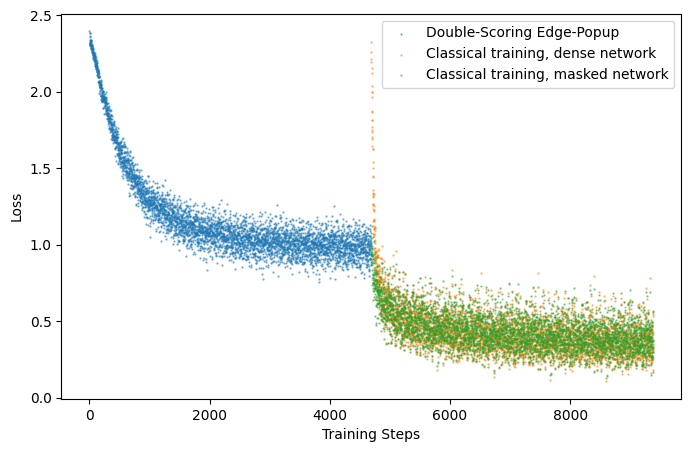

In [2]:
# Experiment outline:
# 1. Train a double-scoring mask on FashionMNIST.
# 2. Freeze the learned mask and retrain the surviving weights as a classical model.
# 3. Compare mask-search, dense, and masked-retraining losses.

epochs = 5
batch_size = 64
layer_sizes=[[28*28,32],[32,10]]

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
train_dataloader = DataLoader(training_data, batch_size=batch_size)
loss_fn = nn.CrossEntropyLoss()
losses_classic = []
losses_masking = []
losses_masking_then_training = []
model_classic = ClassicNetwork(layer_sizes)
model_classic.to(device)
optimizer_classic = torch.optim.Adam(model_classic.parameters())
model_masking = Network(layer_sizes)
model_masking.to(device)
optimizer_masking = torch.optim.Adam(model_masking.parameters())
for t in range(epochs):
    print(f"Epoch {t+1}\n")
    model_classic.train()
    model_masking.train()
    for (X, y) in train_dataloader:
        X,y = X.to(device), y.to(device)
        optimizer_masking.zero_grad()
        pred_masking = model_masking(X)
        loss_masking = loss_fn(pred_masking, y)
        losses_masking.append(loss_masking.item())
        loss_masking.backward()
        optimizer_masking.step()
model_masking.toggle_mode("classic")
for t in range(epochs):
    model_classic.train()
    model_masking.train()
    for (X, y) in train_dataloader:
        X,y = X.to(device), y.to(device)
        optimizer_classic.zero_grad()
        optimizer_masking.zero_grad()
        pred_classic,pred_masking = model_classic(X),model_masking(X)
        loss_classic,loss_masking = loss_fn(pred_classic, y),loss_fn(pred_masking, y)
        losses_classic.append(loss_classic.item())
        losses_masking_then_training.append(loss_masking.item())
        loss_classic.backward()
        optimizer_classic.step()
        loss_masking.backward()
        optimizer_masking.step()

plt.figure(figsize=(8, 5))
plt.scatter([i for i in range(len(losses_masking))],losses_masking,label="Double-Scoring Edge-Popup",s=0.5, alpha=0.5)
plt.scatter(
    [i + len(losses_masking) for i in range(len(losses_classic))],
    losses_classic,
    label="Classical training, dense network",
    s=0.5,
    alpha=0.5,
)
plt.scatter(
    [i + len(losses_masking) for i in range(len(losses_masking_then_training))],
    losses_masking_then_training,
    label="Classical training, masked network",
    s=0.5,
    alpha=0.5,
)
plt.legend()
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.show()